In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

import numpy as np
from src.poisson_hypergraph import GH
from src.simulated_annealing import SimulatedAnnealingApprox
from src.gradient_descent import GradientDescent
import xgi
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
import math

/home/fcataldo/labeled-hypercopy/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [ ]:
def generate_graph_26_starting_nodes(true_theta, timesteps):
    true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er = true_theta
    H = xgi.Hypergraph([[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]])
    H.set_node_attributes({0:0,1:0,2:0,3:0,4:0,5:0,6:0,7:0,8:0,9:0,10:0,11:0,12:0,13:1,14:1,15:1,16:1,17:1,18:1,19:1,20:1,21:1,22:1,23:1,24:1,25:1}, name="label")
    g=GH(H, [0,1], true_p, true_q)
    g.add_hyperedge(timesteps, gamma_nu, gamma_nr, gamma_eu, gamma_er)

    return g

# generating hypergraph parameters
true_p = .8
true_q = .2
gamma_nu, gamma_nr, gamma_eu, gamma_er = .3, .1, 1, 0.25
timesteps = 100
true_theta = [true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er]



In [ ]:
# create new hypergraph
g = generate_graph_26_starting_nodes(true_theta, timesteps)

learning_rate = .01

# momentum parameter
betas = (.9, .99) # defaut .9, .99

gd = GradientDescent(true_theta, g, learning_rate, betas)

max_steps = 200

gd.run(max_steps)

/home/fcataldo/labeled-hypercopy/src/gradient_descent.py:125: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  prob_given_f_u_label_1 = prob_given_f_u_label_1 * (gamma_eu**ext1) * math.exp(-gamma_eu) / math.gamma(ext1+1) / self.generalized_comb(posext1, ext1)


tensor([3689.6218], grad_fn=<SubBackward0>)
tensor([0.8100, 0.5100, 0.5100, 0.5100, 0.5100, 0.5100, 0.5100, 0.5100, 0.5100,
        0.5100, 0.5100, 0.5100, 0.5100, 0.4900, 0.4900, 0.5100, 0.4900, 0.4900,
        0.4900, 0.4900, 0.5100, 0.4900, 0.4900, 0.4900, 0.5100, 0.4900, 0.4900,
        0.4900, 0.5100, 0.4900, 0.5100, 0.4900, 0.5100, 0.5100, 0.4900, 0.4900,
        0.5100, 0.5100, 0.4900, 0.5100, 0.5100, 0.5100, 0.4900, 0.4900, 0.5100,
        0.5100, 0.4900, 0.5100, 0.4912, 0.5100, 0.5100, 0.4923, 0.4900, 0.4901,
        0.5100, 0.4997], dtype=torch.float64, requires_grad=True)
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0]
New label likelihood: -1272.734344425125
New label ari: 0.5545078856371763
tensor([3683.3232], grad_fn=<SubBackward0>)
tensor([0.8197, 0.5200, 0.5200, 0.5200, 0.5200, 0.5200, 0.5200, 0.5200, 0.5199,
        0.5200, 0.5199, 0.5200, 0.5200, 0.

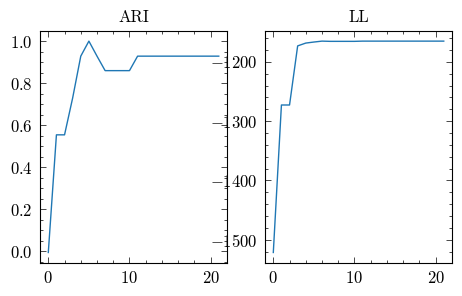

In [4]:
import matplotlib.pyplot as plt
import os
path = os.path.abspath("computermodernstyle.mplstyle")
plt.style.use(path)

def plot_algo_progress(title):
    aris = gd.label_aris
    LLs = gd.label_LLs_converted
    fig, axes = plt.subplots(nrows=1, ncols=2)

    
    axes[0].plot(range(0, len(aris)), aris)
    axes[0].set_title("ARI")
    axes[1].plot(range(0, len(LLs)), LLs)
    axes[1].set_title("LL")
    plt.show()
   

plot_algo_progress("gradient_descent")